# Ice Velocity

- Ice velocity 
    * Description: This dataset contains monthly gridded ice velocity maps of the Antarctic Ice Sheet derived from Sentinel-1 data acquired between 2014-01-01 and 2021-12-31. 
    * Original Data Source: https://opensciencedata.esa.int/products/ice-sheet-velocity-antarctic-2021/collection
    * Reference: https://climate.esa.int/en/projects/ice-sheets-antarctic/
    * OSC entry: https://opensciencedata.esa.int/products/ice-sheet-velocity-antarctic-2021/collection
    * License: CC-BY-NC-4.0
    * Repo Folder: ./datasets/ice_velocity

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

url = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ice_velocity/ice_velocity.zarr/'

In [ ]:
ds = xr.open_zarr(url, chunks={})
ds

/tmp/ipykernel_24827/1939844867.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(url, chunks={"time": 1})


<xarray.Dataset> Size: 2TB
Dimensions:                              (time: 87, y: 24580, x: 28680)
Coordinates:
    crs                                  int32 4B ...
  * time                                 (time) datetime64[ns] 696B 2014-10-0...
  * x                                    (x) float64 229kB -2.868e+06 ... 2.8...
  * y                                    (y) float64 197kB 2.458e+06 ... -2.4...
Data variables:
    land_ice_surface_easting_stddev      (time, y, x) float32 245GB dask.array<chunksize=(1, 1892, 2208), meta=np.ndarray>
    land_ice_surface_easting_velocity    (time, y, x) float32 245GB dask.array<chunksize=(1, 1892, 2208), meta=np.ndarray>
    land_ice_surface_measurement_count   (time, y, x) float64 491GB dask.array<chunksize=(1, 1892, 2208), meta=np.ndarray>
    land_ice_surface_northing_stddev     (time, y, x) float32 245GB dask.array<chunksize=(1, 1892, 2208), meta=np.ndarray>
    land_ice_surface_northing_velocity   (time, y, x) float32 245GB dask.array<chunksize=(1, 1892, 2208), meta=np.ndarray>
    land_ice_surface_velocity_magnitude  (time, y, x) float32 245GB dask.array<chunksize=(1, 1892, 2208), meta=np.ndarray>
    land_ice_surface_vertical_velocity   (time, y, x) float32 245GB dask.array<chunksize=(1, 1892, 2208), meta=np.ndarray>
Attributes: (12/37)
    title:                     Ice Velocity of the Antarctic Ice Sheet
    institution:               ENVEO IT GmbH
    source:                    Copernicus Sentinel-1A and Sentinel-1B
    history:                   Initial product version 1.3
    references:                https://climate.esa.int/en/projects/ice-sheets...
    tracking_id:               7820956a-a125-4b94-a05f-f5161435aa24
    ...                        ...
    standard_name_vocabulary:  CF Standard Name Table v77
    license:                   ESA CCI Data Policy: free and open access
    platform:                  SENTINEL_1A, SENTINEL_1B
    sensor:                    SAR
    spatial_resolution:        200m
    key_variables:             Ice Velocity

In [3]:
# select 2 dates, 6 months apart
t0 = "2019-01-01"
t1 = (xr.DataArray(np.datetime64(t0)).dt.floor("D") + np.timedelta64(183, "D")).values

ds0 = ds.sel(time=t0, method="nearest")
ds1 = ds.sel(time=t1, method="nearest")

ds0.time.values, ds1.time.values

(np.datetime64('2019-01-01T00:00:00.000000000'),
 np.datetime64('2019-07-01T00:00:00.000000000'))

In [4]:
# select variables
vx_name = "land_ice_surface_easting_velocity"
vy_name = "land_ice_surface_northing_velocity"
vv_name = "land_ice_surface_velocity_magnitude"

vx0, vy0, vv0 = ds0[vx_name], ds0[vy_name], ds0[vv_name]
vx1, vy1, vv1 = ds1[vx_name], ds1[vy_name], ds1[vv_name]

In [5]:
# sample values for faster plotting, do not interpolate 
step = 1000

x = ds.x.isel(x=slice(None, None, step))
y = ds.y.isel(y=slice(None, None, step))

vx0c = vx0.isel(x=slice(None, None, step), y=slice(None, None, step))
vy0c = vy0.isel(x=slice(None, None, step), y=slice(None, None, step))
vv0c = vv0.isel(x=slice(None, None, step), y=slice(None, None, step))

vx1c = vx1.isel(x=slice(None, None, step), y=slice(None, None, step))
vy1c = vy1.isel(x=slice(None, None, step), y=slice(None, None, step))
vv1c = vv1.isel(x=slice(None, None, step), y=slice(None, None, step))

In [6]:
# calculate the values
vx0c = vx0c.load()
vy0c = vy0c.load()
vv0c = vv0c.load()

vx1c = vx1c.load()
vy1c = vy1c.load()
vv1c = vv1c.load()

X, Y = np.meshgrid(x.values, y.values)

speed = xr.concat([vv0c, vv1c], dim="plot_time").values
finite_speed = speed[np.isfinite(speed)]

vmin = np.nanpercentile(finite_speed, 2)
vmax = np.nanpercentile(finite_speed, 98)

In [7]:
antarctic_crs = ccrs.SouthPolarStereo(
    central_longitude=0,
    true_scale_latitude=-71,
)

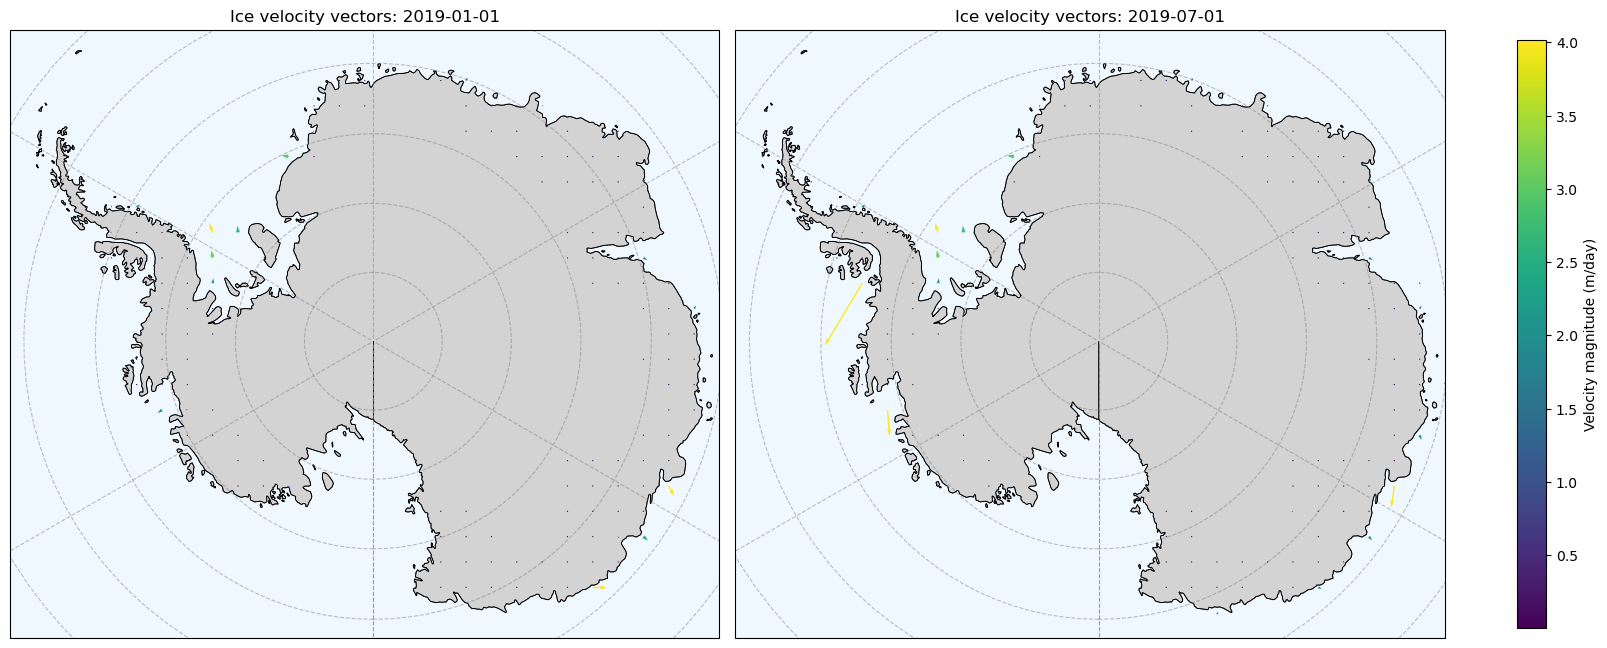

In [8]:
extent = [
    float(x.values.min()),
    float(x.values.max()),
    float(y.values.min()),
    float(y.values.max()),
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    subplot_kw={"projection": antarctic_crs},
    constrained_layout=True,
)

for ax in axes:
    ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", linewidth=0.4, zorder=1)
    ax.coastlines(resolution="50m", color="black", linewidth=0.7, zorder=2)
    ax.gridlines(draw_labels=False, color="gray", alpha=0.5, linestyle="--")
    ax.set_extent(extent, crs=antarctic_crs)


q0 = axes[0].quiver(
    X, Y,
    vx0c.values, vy0c.values,
    vv0c.values,
    cmap="viridis",
    clim=(vmin, vmax),
    angles="xy",
    scale_units="xy",
    scale=0.00005,
    width=0.002,
    transform=antarctic_crs,
    zorder=3,
)
axes[0].set_aspect("equal")
axes[0].set_title(f"Ice velocity vectors: {np.datetime_as_string(ds0.time.values, unit='D')}")
axes[0].set_xlabel("Easting x (m)")
axes[0].set_ylabel("Northing y (m)")


q1 = axes[1].quiver(
    X, Y,
    vx1c.values, vy1c.values,
    vv1c.values,
    cmap="viridis",
    clim=(vmin, vmax),
    angles="xy",
    scale_units="xy",
    scale=0.00005,
    width=0.002,
    transform=antarctic_crs,
    zorder=3,
)
axes[1].set_aspect("equal")
axes[1].set_title(f"Ice velocity vectors: {np.datetime_as_string(ds1.time.values, unit='D')}")
axes[1].set_xlabel("Easting x (m)")
axes[1].set_ylabel("Northing y (m)")

fig.colorbar(q1, ax=axes, label="Velocity magnitude (m/day)", shrink=0.85)

plt.show()